In the Model Training Notebook, we have used the Original Preprocessed Dataset (data_matrix1.npy) for model training.

In the Model_training2.ipynb, the preprocessed data with VIF signified multicollinear features removed (data_matrix_reduced1.npy) as been used in model training

In [1]:
import numpy as np 
import pandas as pd 

preprocess_dir = f"../data_analysis1/artifacts/preprocess"
models_dir = f"../data_analysis1/artifacts/models"

X = np.load(f"{preprocess_dir}/data_matrix1.npy")
X_reduced = np.load(f"{preprocess_dir}/data_matrix_reduced.npy")
X_reduced_1 = np.load(f"{preprocess_dir}/data_matrix_reduced1.npy")

y = np.load(f"{preprocess_dir}/y.npy")

import joblib
import json

drop_cols = joblib.load(f"{preprocess_dir}/data_matrix_drop_cols.joblib")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning:

In [3]:
X.shape , X_reduced.shape , X_reduced_1.shape

((85849, 139), (85849, 131), (85849, 72))

In [4]:
y.shape

(85849,)

In [5]:
np.unique(y,return_counts=True)

(array([1, 2, 3, 4, 5]), array([11213,  1282,  2557, 11210, 59587]))

In [6]:
drop_cols

{'corr_drop_cols': [0, 2, 4, 18, 20, 21, 23, 27],
 'vif_drop_cols': array([ 0,  4,  5,  6,  9, 10, 11, 12, 13, 20, 21, 22, 23, 24, 25, 26, 27,
        28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45,
        46, 47, 49, 50, 51, 52, 53, 55, 57, 58, 59, 60, 61, 62, 63, 64, 65,
        66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 79, 80, 83, 84, 85, 86])}

In [7]:
drop_cols_1 = drop_cols["corr_drop_cols"]
drop_cols_2 = drop_cols["vif_drop_cols"]


In [8]:
import warnings 
warnings.filterwarnings('ignore')

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization, Flatten 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy , Precision , Recall,AUC


In [10]:
len(drop_cols_1), len(drop_cols_2)

(8, 67)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [12]:
np.unique(y , return_counts=True)

(array([1, 2, 3, 4, 5]), array([11213,  1282,  2557, 11210, 59587]))

In [13]:
import json 
with open(f'{preprocess_dir}/class_weights.json','r') as file:
    class_weights = json.load(file)


print(class_weights)

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}


In [14]:
xtrain ,  xtest ,ytrain ,ytest = train_test_split(X , y , test_size = 0.1 , stratify = y , random_state=7)
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 139), (77264,), (8585, 139), (8585,))

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np





def evaluate_classification_model1(model, X_train, y_train, X_test, y_test):
    """ This function evaluates a classification model using macro averaging for metrics whereever applicable."""
    
    results = {}

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for ROC AUC if available (multiclass classification)
    y_train_prob = model.predict_proba(X_train) if hasattr(model, "predict_proba") else None
    y_test_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calculate metrics helper - Macro averaging for multiclass classification because of class imbalance - to give equal importance to all classes
    def calc_metrics(y_true, y_pred, y_prob=None):
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0, average='macro')
        recall = recall_score(y_true, y_pred, zero_division=0, average='macro')
        f1 = f1_score(y_true, y_pred, zero_division=0, average='macro')
        roc_auc = (
            roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr')
            if y_prob is not None
            else None
        )
        return accuracy, precision, recall, f1, roc_auc

    train_metrics = calc_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = calc_metrics(y_test, y_test_pred, y_test_prob)

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

    # Print metrics
    print("Training Metrics:")
    for name, value in zip(metric_names, train_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    print("\nTesting Metrics:")
    for name, value in zip(metric_names, test_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    # Detailed classification report for test
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Confusion matrix plot for test data
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curves per class for multiclass data (One-vs-Rest)
    if y_test_prob is not None:
        classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=classes)
        n_classes = y_test_binarized.shape[1]

        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_prob[:, i])
            roc_auc = roc_auc_score(y_test_binarized[:, i], y_test_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curve (One-vs-Rest)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}


In [16]:
lr = LogisticRegression(random_state = 7 , verbose = 1 , n_jobs=-1)
lr.fit(xtrain,ytrain)

print(lr.score(xtrain,ytrain))
print(lr.score(xtest,ytest))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


0.7172292400082833
0.7168316831683168


Training Metrics:
Accuracy: 0.7172
Precision: 0.2746
Recall: 0.2493
F1 Score: 0.2413
ROC AUC: 0.6801

Testing Metrics:
Accuracy: 0.7168
Precision: 0.2726
Recall: 0.2514
F1 Score: 0.2436
ROC AUC: 0.6637

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.64      0.28      0.39      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.27      0.25      0.24      8585
weighted avg       0.58      0.72      0.63      8585



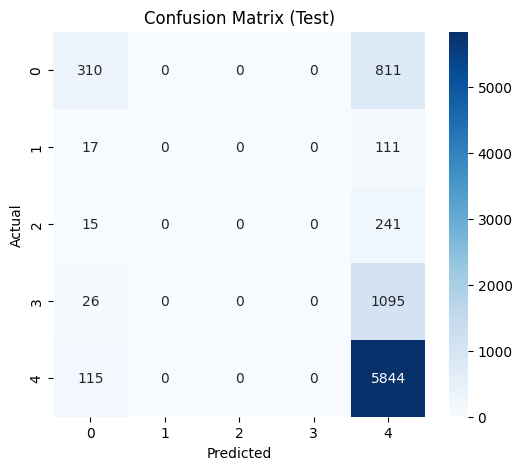

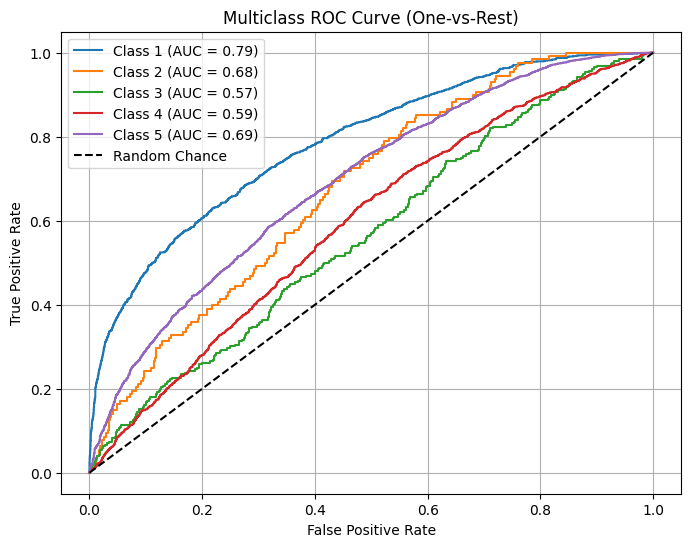

In [17]:
lr_train_metrics, lr_test_metrics = evaluate_classification_model1(lr, xtrain, ytrain, xtest, ytest)

We can see that Accuracy is 71% which means 71% records are being correctly predicted by the Model.However it is to note that the target classes are highly imbalanced. So accuracy is not a very powerful signal for good model performance. It might be just correctly predicting the majority which completely failing in the minority classes and even then it will be having a high accuracy.

Precision is very low indicating high false positives. For multiclass classification it means the high false positives on average for all the classes.
Similarly low recall means high False Negatives.

Classification Report for test data shows that model is giving good precision and recall for Class 5 comparatively. Class 5 is the majority class of all. For this class low false positives and very low false negatives. But of the class 2,3,4 the scores of all metrics are 0 - the model is completely avoiding to predict these clases. TP = 0 for all these classes.


In [18]:

lr1 = LogisticRegression(max_iter=1000 , random_state = 7 , n_jobs=-1 )
lr1.fit(xtrain,ytrain)

print(lr1.score(xtrain,ytrain))
print(lr1.score(xtest,ytest))

0.717358666390557
0.7172976121141525


Training Metrics:
Accuracy: 0.7174
Precision: 0.2747
Recall: 0.2495
F1 Score: 0.2415
ROC AUC: 0.6809

Testing Metrics:
Accuracy: 0.7173
Precision: 0.2738
Recall: 0.2519
F1 Score: 0.2441
ROC AUC: 0.6636

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.65      0.28      0.39      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.27      0.25      0.24      8585
weighted avg       0.59      0.72      0.63      8585



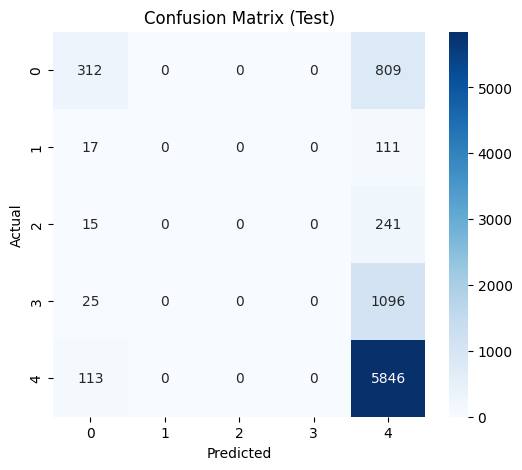

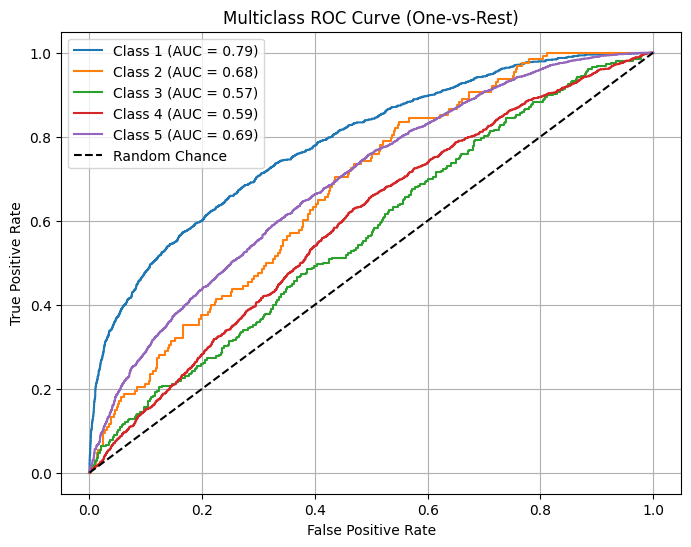

In [19]:
lr1_train_metrics, lr1_test_metrics = evaluate_classification_model1(lr1, xtrain, ytrain, xtest, ytest)

# Lower precision_score indicates higher cases of False Positives.Since it is multiclass classification , it indicates that some classes are being misclassified as other classes.


# Lower recall score indicates higher cases of False negatives.Since it is macro recall , it takes the arithmetic mean of all class recalls , treating all classes equally regardless of their frequency.Thereby the lower macro recall indicates that the model is giving higher number of false negatives across overall all classes.

# ROC AUC = 0.66 means that the model has a 66% chance of distinguishing between classes, which is better than random guessing but indicates room for improvement.This is macro roc : all classes ROC averaged.

# Classification report precision,recall , f1 are 0 for 2 , 3 , 4 indicates that the model is not predicting any instances of these classes correctly, likely due to class imbalance or insufficient training data for these classes.It indicates that TP = 0 for these classes. 
# Similarly recall is also 0 for these classes indicating that the model is not able to identify any actual instances of these classes correctly.
# Overall , the model performs well on the majority class (class 5) and the class 1 , but struggles with minority classes (2, 3, 4) likely due to class imbalance.



In [20]:
class_weights

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}

In [21]:
class_weights_int = {int(key) : value for key , value in class_weights.items()}
class_weights_int

{5: 1.44, 1: 7.65, 4: 7.66, 3: 33.58, 2: 66.96}

In [22]:
# Linear regression with class weights to handle class imbalance
lr2 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=7)
lr2.fit(xtrain,ytrain)

print(lr2.score(xtrain,ytrain))
print(lr2.score(xtest,ytest))

0.37918047214744255
0.380547466511357


Training Metrics:
Accuracy: 0.3792
Precision: 0.2915
Recall: 0.3303
F1 Score: 0.2582
ROC AUC: 0.6627

Testing Metrics:
Accuracy: 0.3805
Precision: 0.2907
Recall: 0.3037
F1 Score: 0.2530
ROC AUC: 0.6367

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.40      0.46      0.43      1121
           2       0.02      0.22      0.04       128
           3       0.03      0.16      0.05       256
           4       0.16      0.28      0.20      1121
           5       0.84      0.40      0.54      5959

    accuracy                           0.38      8585
   macro avg       0.29      0.30      0.25      8585
weighted avg       0.66      0.38      0.46      8585



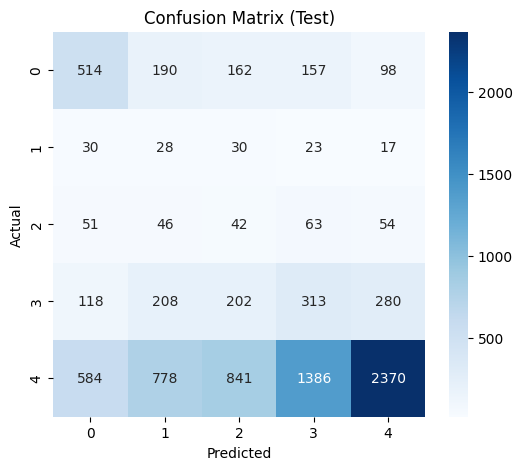

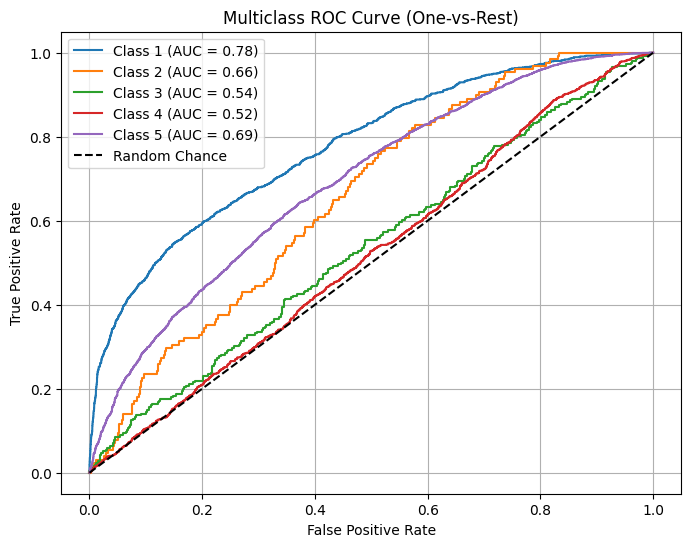

In [23]:
lr2_train_metrics, lr2_test_metrics = evaluate_classification_model1(lr2, xtrain, ytrain, xtest, ytest)

With the addition class weights, The minority class performance metrics had shown as slight improvement especially for class 4 but even then the performance is very low.

Also the recall had significantly reduced for the majority class 5 meaning higher False Negatives for the class. 

In [24]:
lr3 = LogisticRegression(max_iter=1000 , class_weight=class_weights_int, random_state=7)
lr3.fit(xtrain,ytrain)

print(lr3.score(xtrain,ytrain))
print(lr3.score(xtest,ytest))

0.3783392006626631
0.37833430401863716


Creating RF , XGB , DNN for this dataset 

In [25]:
rf1 = RandomForestClassifier(random_state = 7,n_jobs=-1 , n_estimators=200 , max_depth=10)

rf1.fit(xtrain,ytrain)

print(rf1.score(xtrain,ytrain))
print(rf1.score(xtest,ytest))

0.717151584178919
0.7160163075131043


Training Metrics:
Accuracy: 0.7172
Precision: 0.3088
Recall: 0.2382
F1 Score: 0.2293
ROC AUC: 0.7543

Testing Metrics:
Accuracy: 0.7160
Precision: 0.2989
Recall: 0.2388
F1 Score: 0.2298
ROC AUC: 0.6630

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.78      0.20      0.32      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.71      0.99      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.30      0.24      0.23      8585
weighted avg       0.60      0.72      0.62      8585



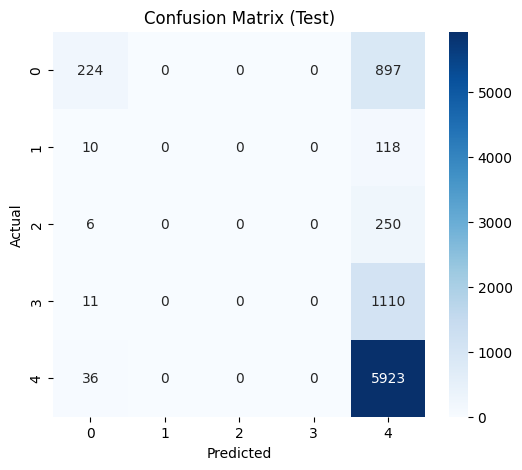

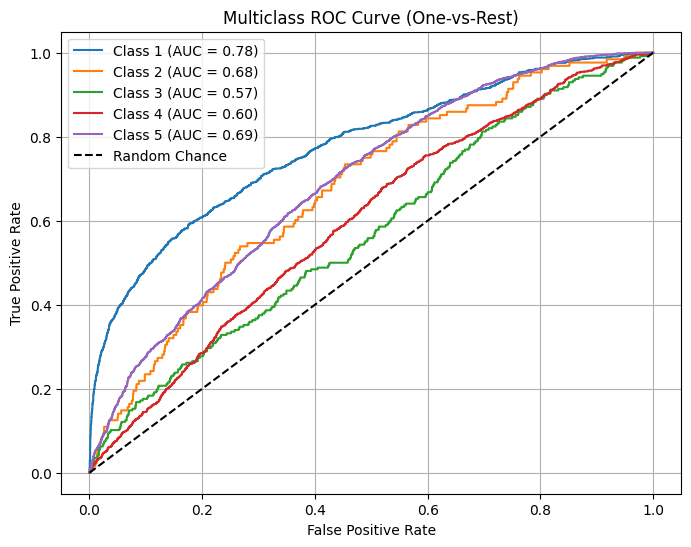

In [26]:
rf1_train_metrics, rf1_test_metrics = evaluate_classification_model1(rf1, xtrain , ytrain , xtest , ytest)

In [27]:
rf2 = RandomForestClassifier(random_state = 7,n_jobs=-1 , n_estimators=200 , max_depth=10 , class_weight='balanced')

rf2.fit(xtrain,ytrain)

print(rf2.score(xtrain,ytrain))
print(rf2.score(xtest,ytest))

0.4471681507558501
0.41059988351776355


Training Metrics:
Accuracy: 0.4472
Precision: 0.3344
Recall: 0.4578
F1 Score: 0.3277
ROC AUC: 0.7650

Testing Metrics:
Accuracy: 0.4106
Precision: 0.2919
Recall: 0.3121
F1 Score: 0.2655
ROC AUC: 0.6411

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.39      0.50      0.44      1121
           2       0.03      0.13      0.04       128
           3       0.03      0.15      0.06       256
           4       0.17      0.36      0.23      1121
           5       0.84      0.42      0.56      5959

    accuracy                           0.41      8585
   macro avg       0.29      0.31      0.27      8585
weighted avg       0.66      0.41      0.48      8585



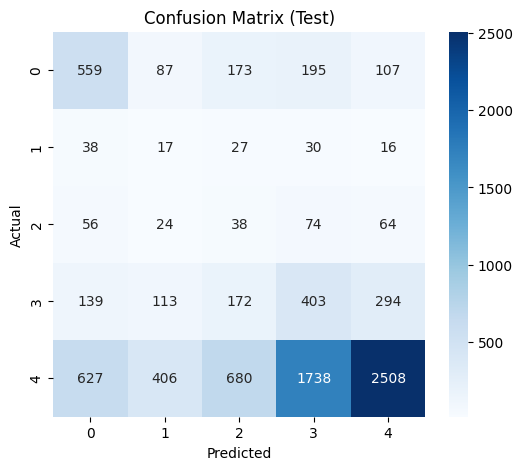

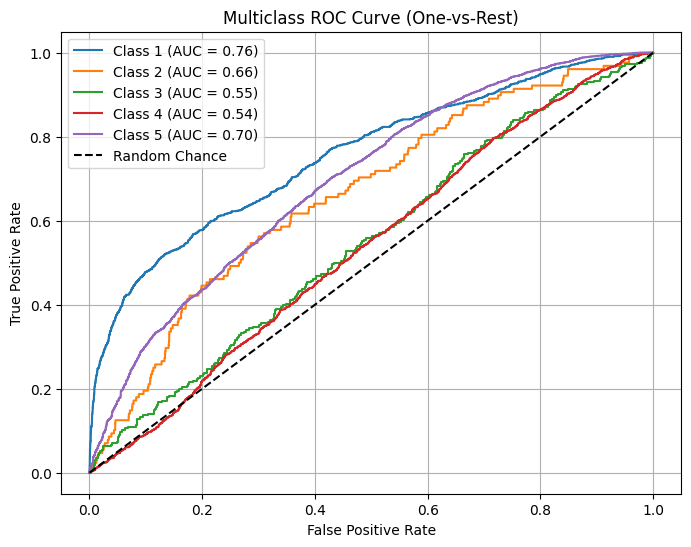

In [28]:
rf2_train_metrics, rf2_test_metrics=evaluate_classification_model1(rf2, xtrain , ytrain , xtest , ytest)

In [29]:
rf3 = RandomForestClassifier(random_state = 7,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf3.fit(xtrain,ytrain)

print(rf3.score(xtrain,ytrain))
print(rf3.score(xtest,ytest))

0.8806559329053635
0.6260920209668026


Training Metrics:
Accuracy: 0.8807
Precision: 0.7874
Recall: 0.8811
F1 Score: 0.8253
ROC AUC: 0.9615

Testing Metrics:
Accuracy: 0.6261
Precision: 0.2904
Recall: 0.2888
F1 Score: 0.2891
ROC AUC: 0.6417

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.45      0.45      0.45      1121
           2       0.02      0.01      0.01       128
           3       0.04      0.05      0.05       256
           4       0.17      0.16      0.16      1121
           5       0.76      0.79      0.78      5959

    accuracy                           0.63      8585
   macro avg       0.29      0.29      0.29      8585
weighted avg       0.61      0.63      0.62      8585



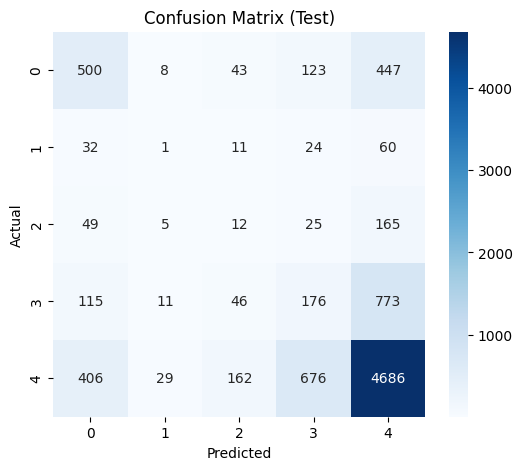

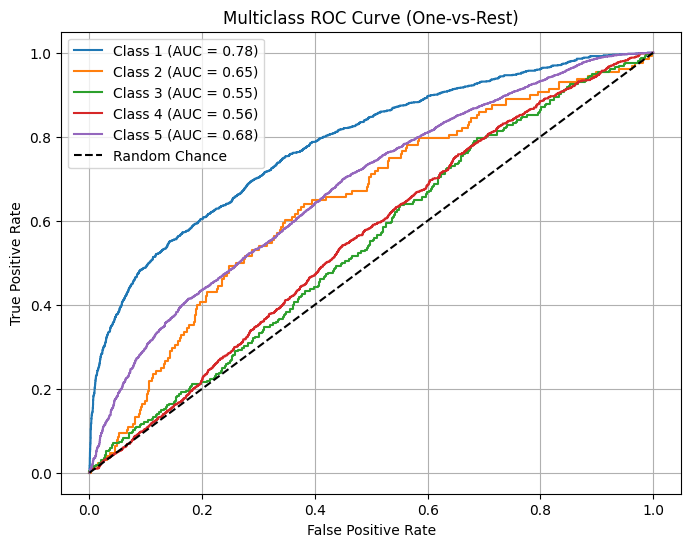

In [30]:
rf3_train_metrics, rf3_test_metrics = evaluate_classification_model1(rf3, xtrain, ytrain, xtest, ytest)

In [31]:
class_weights_int_xgb = {key-1 : value for key, value in class_weights_int.items()}
class_weights_int_xgb

{4: 1.44, 0: 7.65, 3: 7.66, 2: 33.58, 1: 66.96}

In [32]:
# Trying XGB

classes = np.unique(y)-1 # [0, 1, 2, 3, 4] because xgboost expects class labels to start from 0
sample_weights = np.array([class_weights_int_xgb[label] for label in ytrain-1]) # array containing weights for each ytrain instance based on its class label. 


xgb1 = XGBClassifier(random_state=7,objective = 'multi:softmax' )
xgb1.fit(xtrain, ytrain-1, sample_weight=sample_weights)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
xgb1.score(xtrain,ytrain-1) , xgb1.score(xtest,ytest-1)

(0.5406657693104162, 0.43296447291788004)

Training Metrics:
Accuracy: 0.5407
Precision: 0.4043
Recall: 0.6454
F1 Score: 0.4252
ROC AUC: 0.8553

Testing Metrics:
Accuracy: 0.4330
Precision: 0.2836
Recall: 0.2930
F1 Score: 0.2628
ROC AUC: 0.6390

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.39      0.47      0.42      1121
           1       0.02      0.09      0.03       128
           2       0.04      0.14      0.06       256
           3       0.16      0.30      0.21      1121
           4       0.82      0.47      0.60      5959

    accuracy                           0.43      8585
   macro avg       0.28      0.29      0.26      8585
weighted avg       0.64      0.43      0.50      8585



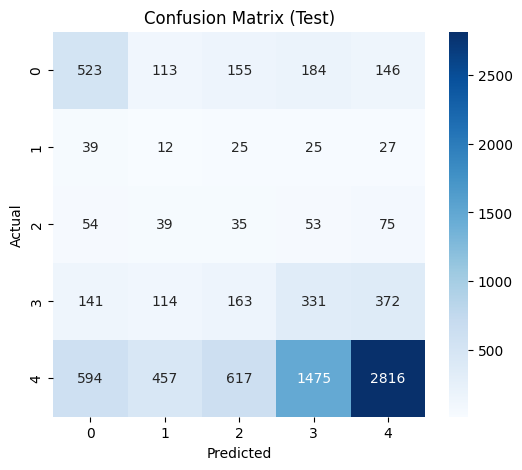

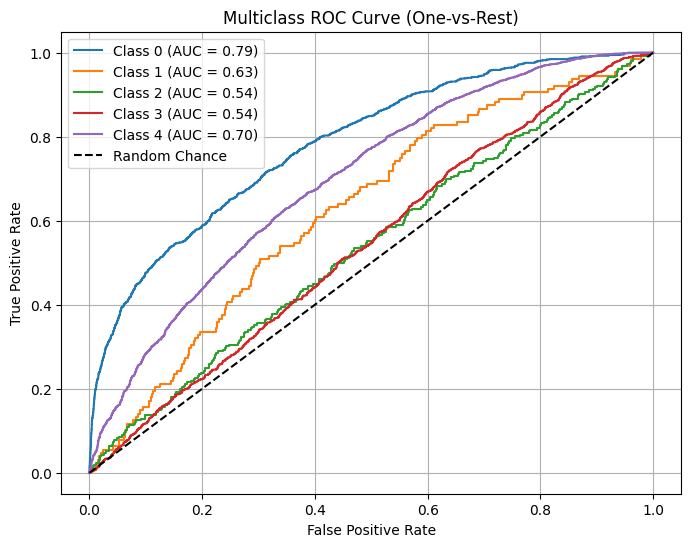

In [34]:
xgb1_train_metrics, xgb1_test_metrics=evaluate_classification_model1(xgb1, xtrain, ytrain-1, xtest, ytest-1)

In [35]:
xgb2 = XGBClassifier(random_state=7,
         n_estimators = 200,
         max_depth = 20,
         learning_rate = 0.1,
         objective = 'multi:softmax' ) # softmax for multiclass labels and softprob for multiclass probabilities
xgb2.fit(xtrain, ytrain-1, sample_weight=sample_weights)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
xgb2.score(xtrain,ytrain-1) , xgb2.score(xtest,ytest-1)

(0.999585835576724, 0.6732673267326733)

Training Metrics:
Accuracy: 0.9996
Precision: 0.9992
Recall: 0.9999
F1 Score: 0.9996
ROC AUC: 1.0000

Testing Metrics:
Accuracy: 0.6733
Precision: 0.3043
Recall: 0.2710
F1 Score: 0.2705
ROC AUC: 0.6354

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.46      0.38      0.42      1121
           1       0.11      0.01      0.01       128
           2       0.03      0.00      0.01       256
           3       0.18      0.08      0.11      1121
           4       0.74      0.88      0.80      5959

    accuracy                           0.67      8585
   macro avg       0.30      0.27      0.27      8585
weighted avg       0.60      0.67      0.63      8585



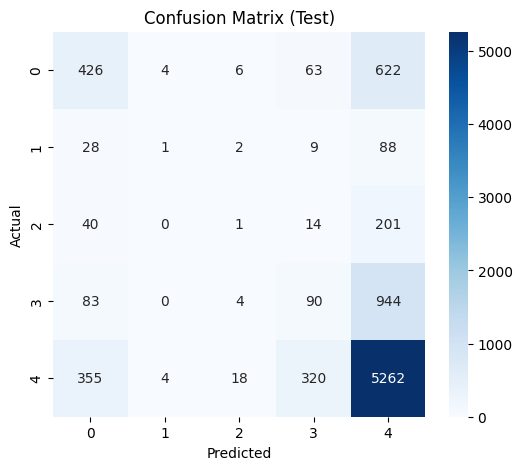

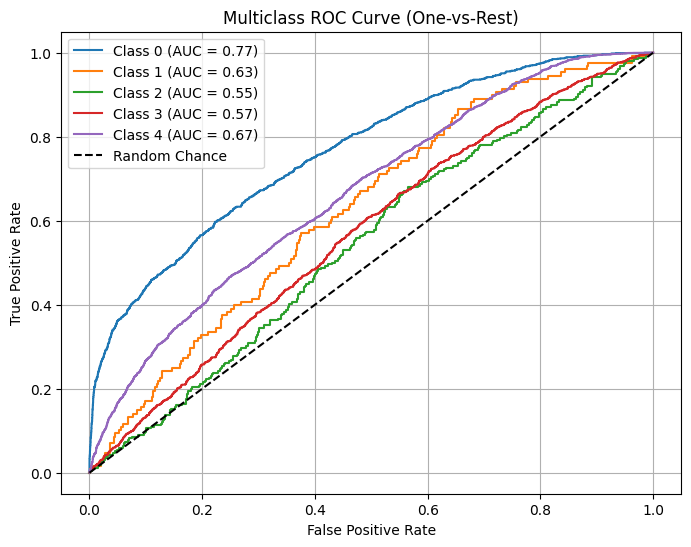

In [37]:
xgb2_train_metrics, xgb2_test_metrics=evaluate_classification_model1(xgb2, xtrain, ytrain-1, xtest, ytest-1)

XGB with optimized Hyperparameters is showing good perfomance on training. But on test classification report it can be seen that the model is overfitting. It is learning noise in the data during training. Metrics Performances of Class 2, 3, 4 are not good enough. For Class 1 they are pretty mediocre. For Class 5 , it is performing good in recall and precision.

Now trying ann models

In [38]:
import tensorflow as tf
tf.__version__

'2.20.0-rc0'

In [39]:
classes = np.unique(y)-1
n_classes = len(classes)

In [44]:

# Model creation
ann1 = Sequential()
ann1.add(Input(shape=(xtrain.shape[1],)))
ann1.add(Dense(128, activation='relu',))
ann1.add(Dense(64 , activation = 'relu'))
ann1.add(Dense(n_classes , activation = 'softmax') )

ann1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,501 (103.52 KB)

 Trainable params: 26,501 (103.52 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Model_compilation



ann1.compile(optimizer=Adam(learning_rate=0.01), 
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [46]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 20,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)


In [47]:
# Fit the model 

history = ann1.fit(xtrain, ytrain-1,
                   validation_data=(xtest, ytest-1), epochs=100, 
                   batch_size=32,
             callbacks = [reduce_lr , early_stop])    

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7132 - loss: 0.8818 - val_accuracy: 0.7164 - val_loss: 0.8697 - learning_rate: 0.0100
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7171 - loss: 0.8675 - val_accuracy: 0.7176 - val_loss: 0.8632 - learning_rate: 0.0100
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7165 - loss: 0.8661 - val_accuracy: 0.7187 - val_loss: 0.8745 - learning_rate: 0.0100
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7176 - loss: 0.8654 - val_accuracy: 0.7162 - val_loss: 0.8674 - learning_rate: 0.0100
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7180 - loss: 0.8636 - val_accuracy: 0.7161 - val_loss: 0.8644 - learning_rate: 0.0100
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - accuracy: 0.7181 - loss: 0.8622 - val_accuracy: 0.7180 - val_loss: 0.8627 - learning_rate: 0.0100
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0

In [48]:

# Plot Loss

def performance_plots(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy (or another metric you used, e.g. precision)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()



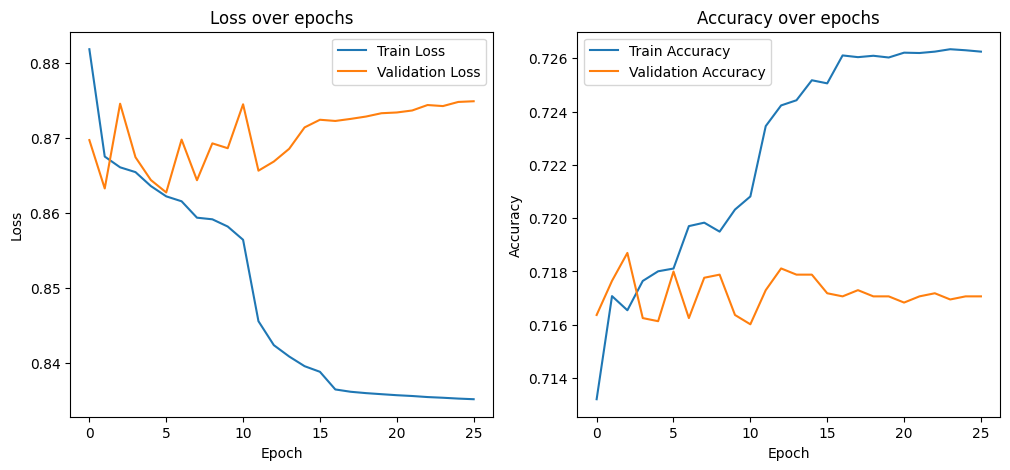

In [49]:

performance_plots(history)

The graphs shows that the model reached its peak performance quite early in the epochs and thereafter no further improvement happened on loss decrease and accuracy increase . The accuracy became stagnant at 0.6941 for both training and validation sets . The models shows not overfitting.

In [102]:

def metrics_eval(model, X_test, y_test):
    
    y_pred_prob = model.predict(X_test)

    # Binary sigmoid output
    if y_pred_prob.shape[1] == 1:
        y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    # Multiclass / softmax output
    else:
        y_pred = np.argmax(y_pred_prob, axis=1)
 # Macro averaging gives equal weights to all classes regardless of their frequency, which is useful in imbalanced datasets.
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")


In [51]:

metrics_eval(ann1, xtest, ytest-1)



269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step
F1 Score : 0.2390
Precision: 0.2839
Recall: 0.2466


The Model 1 showed Underfitting. It had accuracy of 70%, it surely means that it is just correctly predicting the majority class. Poor Macro Recall and Poor Macro Precision confirms it.

ANN model2 : Making it more deeper and there complex that may be able to capture more underlying patterns in the data to reduce the bias occuring in the model training

In [52]:
# Model creation

ann2 = Sequential()
ann2.add(Input(shape=(xtrain.shape[1],)))
ann2.add(Dense(256, activation='relu',))
ann2.add(Dense(128, activation='relu',))
ann2.add(Dense(64 , activation = 'relu'))
ann2.add(Dense(n_classes , activation = 'softmax') )

ann2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,317 (302.02 KB)

 Trainable params: 77,317 (302.02 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Model_compilation

ann2.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])


In [54]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 15,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)

# Fit the model 

history1 = ann1.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=100, batch_size=32,
                    callbacks = [reduce_lr , early_stop])    





Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7211 - loss: 0.8531 - val_accuracy: 0.7179 - val_loss: 0.8606 - learning_rate: 1.0000e-04
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7217 - loss: 0.8514 - val_accuracy: 0.7179 - val_loss: 0.8604 - learning_rate: 1.0000e-04
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7219 - loss: 0.8506 - val_accuracy: 0.7183 - val_loss: 0.8602 - learning_rate: 1.0000e-04
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7221 - loss: 0.8500 - val_accuracy: 0.7183 - val_loss: 0.8601 - learning_rate: 1.0000e-04
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7222 - loss: 0.8495 - val_accuracy: 0.7186 - val_loss: 0.8601 - learning_rate: 1.0000e-04
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7223 - loss: 0.8491 - val_accuracy: 0.7181 - val_loss: 0.8604 - learning_rate: 1.0000e-04
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 

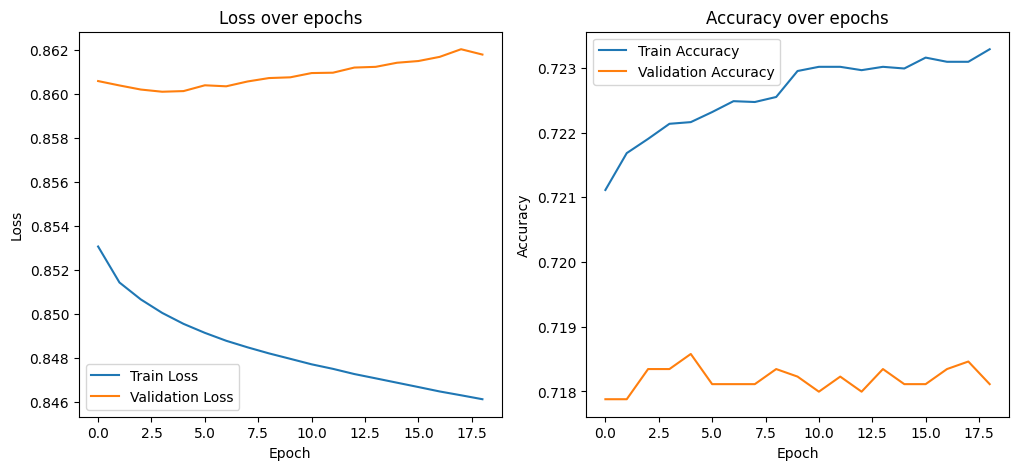

In [55]:
performance_plots(history1)

In [56]:
#Evaluate metrics : Precision , Recall , F1 score 

metrics_eval(ann2, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step
F1 Score : 0.1561
Precision: 0.2004
Recall: 0.2003


Ann Model new with class_weights

In [57]:
# Model creation

ann_new = Sequential()
ann_new.add(Input(shape=(xtrain.shape[1],)))
ann_new.add(Dense(256, activation='relu',))
ann_new.add(Dense(128, activation='relu',))
ann_new.add(Dense(64 , activation = 'relu'))
ann_new.add(Dense(n_classes , activation = 'softmax') )

ann_new.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,317 (302.02 KB)

 Trainable params: 77,317 (302.02 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Model_compilation

ann_new.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])


In [59]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 10,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)

# Fit the model 

history_new = ann_new.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=100, batch_size=32,
                    callbacks = [reduce_lr , early_stop] , class_weight=class_weights_int)    





Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.5705 - loss: 13.3391 - val_accuracy: 0.1563 - val_loss: 1.4372 - learning_rate: 0.0100
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5600 - loss: 13.1557 - val_accuracy: 0.6375 - val_loss: 1.3403 - learning_rate: 0.0100
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5669 - loss: 13.0864 - val_accuracy: 0.5713 - val_loss: 1.3649 - learning_rate: 0.0100
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5664 - loss: 13.0687 - val_accuracy: 0.6672 - val_loss: 1.2744 - learning_rate: 0.0100
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5664 - loss: 13.0914 - val_accuracy: 0.6139 - val_loss: 1.3179 - learning_rate: 0.0100
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5535 - loss: 13.0650 - val_accuracy: 0.5765 - val_loss: 1.3868 - learning_rate: 0.0100
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accurac

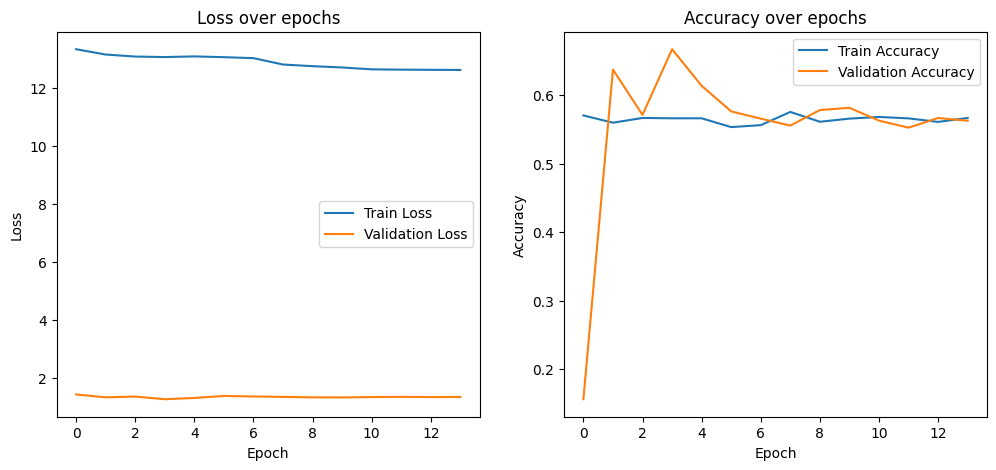

In [60]:
performance_plots(history_new)

In [61]:
#Evaluate metrics : Precision , Recall , F1 score 

metrics_eval(ann_new, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step
F1 Score : 0.1814
Precision: 0.1687
Recall: 0.2034


Turning the multi class classification problem to binary classification (satisfied or not satisfied customers)

In [62]:
# y binarized

def binarize(y):
    return np.where(y >= 3, 1, 0)


# y_binarized = binarize(y)

In [63]:
ytrain_binarized = binarize(ytrain)
ytest_binarized = binarize(ytest)

print(np.unique(ytrain_binarized , return_counts= True))

print(np.unique(ytest_binarized , return_counts= True))

(array([0, 1]), array([11246, 66018]))
(array([0, 1]), array([1249, 7336]))


After binarization we can see that minority class 1/6th times the majority class in both the arrays.

Model creation for binary classification


In [64]:
lr3 = LogisticRegression(random_state=7)
lr3.fit(xtrain,ytrain_binarized)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,7
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:


def evaluate_binary_classification(model, X_train, y_train, X_test, y_test):
    """
    Evaluate a binary classification model with metrics and visualizations.
    """
    
    # Step 1: Get predictions (0 or 1)
    y_train_pred = (model.predict(X_train) > 0.5).astype(int)
    y_test_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Step 2: Get probabilities (for ROC-AUC calculation)
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()
    
    # Step 3: Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_roc_auc = roc_auc_score(y_train, y_train_prob)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    
    # Step 4: Print metrics
    print("=" * 50)
    print("TRAINING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall:    {train_recall:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")
    print(f"ROC AUC:   {train_roc_auc:.4f}")
    
    print("\n" + "=" * 50)
    print("TESTING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"ROC AUC:   {test_roc_auc:.4f}")
    
    # Step 5: Print detailed classification report
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT (TEST DATA)")
    print("=" * 50)
    print(classification_report(y_test, y_test_pred))
    
    # Step 6: Plot confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix (Test Data)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    # Step 7: Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_roc_auc": test_roc_auc
    }




TRAINING METRICS
Accuracy:  0.8745
Precision: 0.8810
Recall:    0.9864
F1 Score:  0.9307
ROC AUC:   0.6021

TESTING METRICS
Accuracy:  0.8742
Precision: 0.8826
Recall:    0.9836
F1 Score:  0.9304
ROC AUC:   0.6075

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.71      0.23      0.35      1249
           1       0.88      0.98      0.93      7336

    accuracy                           0.87      8585
   macro avg       0.79      0.61      0.64      8585
weighted avg       0.86      0.87      0.85      8585



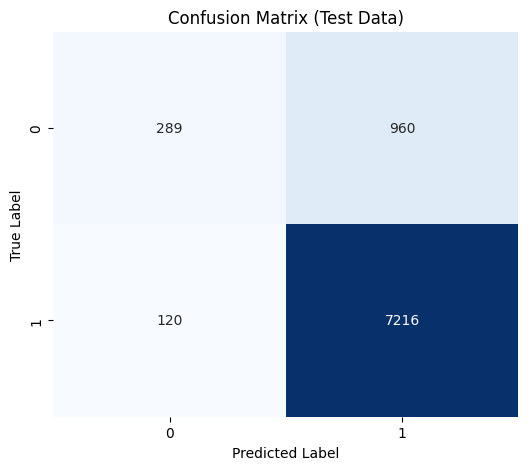

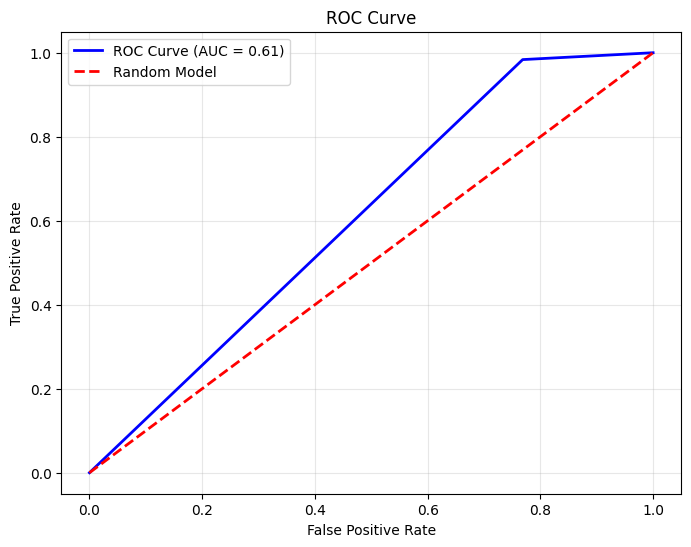

{'test_accuracy': 0.8741991846243448,
 'test_precision': 0.8825831702544031,
 'test_recall': 0.9836423118865867,
 'test_f1': 0.9303764827230531,
 'test_roc_auc': 0.607513709986528}

In [66]:
evaluate_binary_classification(lr3 , xtrain,ytrain_binarized,xtest,ytest_binarized)

Based on the Classification Report for the test data ->
Based on Dissatisfied customers metrics:
1. Out of 100 times, model predicting a dissatisfied customer, 67 times the customer turns out to be of satisfied customer class.
2. Out of 100 times, model predicting a customer as satisfied, 37 times it came out to be dissatisfied. 

Based on satisfied Customer(1) class metrics:
1. Out of 100 times model predicting as satified customer,8 times the customer turns out to be dissatisfied.

Out of 100, model predicting customer as not satified(dissatisfied), 22 times it came out to be satisfied customer.


Note : For Our Problem, We want to correctly detect the dissatisfied customer so that the company can try to connect with them or resolve their satisfaction. So we Want to focus on increasing the Recall(lower FN) for the class 0 (dissatisfied customers). This will our Primary metric to improve.

In [67]:
lr4 = LogisticRegression(max_iter=500 , class_weight='balanced', random_state=7)
lr4.fit(xtrain,ytrain_binarized)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,7
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


TRAINING METRICS
Accuracy:  0.7480
Precision: 0.9264
Recall:    0.7659
F1 Score:  0.8385
ROC AUC:   0.7044

TESTING METRICS
Accuracy:  0.7475
Precision: 0.9240
Recall:    0.7676
F1 Score:  0.8386
ROC AUC:   0.6984

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.32      0.63      0.42      1249
           1       0.92      0.77      0.84      7336

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



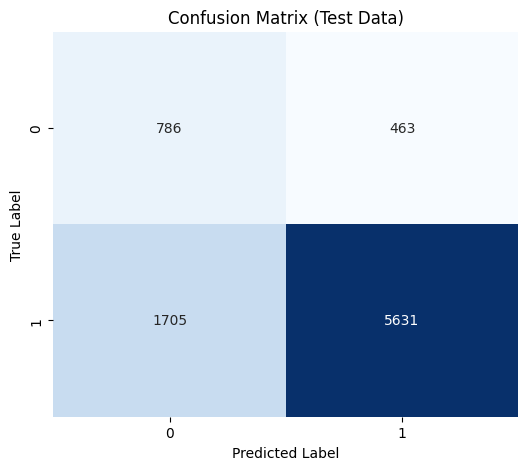

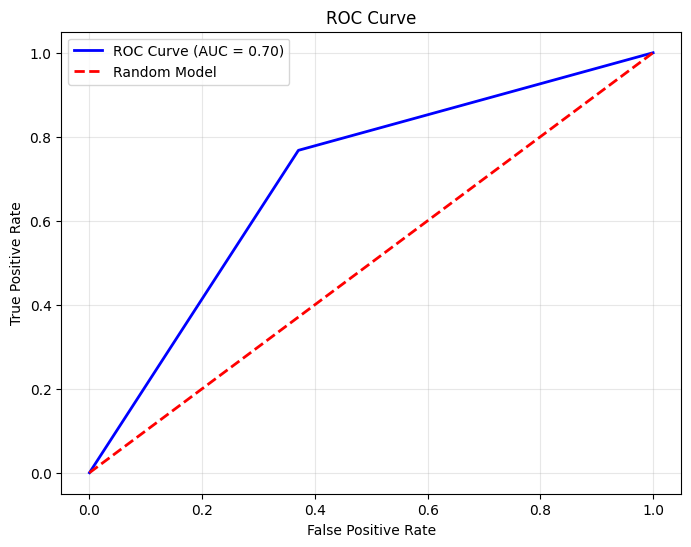

{'test_accuracy': 0.747466511357018,
 'test_precision': 0.9240236297998031,
 'test_recall': 0.7675845147219194,
 'test_f1': 0.8385703648548026,
 'test_roc_auc': 0.6984439787380614}

In [68]:
evaluate_binary_classification(lr4 , xtrain,ytrain_binarized,xtest,ytest_binarized)

In [69]:
lr5 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=7 , n_jobs=-1)
lr5.fit(xtrain,ytrain_binarized)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,7
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


TRAINING METRICS
Accuracy:  0.7480
Precision: 0.9264
Recall:    0.7659
F1 Score:  0.8385
ROC AUC:   0.7044

TESTING METRICS
Accuracy:  0.7475
Precision: 0.9240
Recall:    0.7676
F1 Score:  0.8386
ROC AUC:   0.6984

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.32      0.63      0.42      1249
           1       0.92      0.77      0.84      7336

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



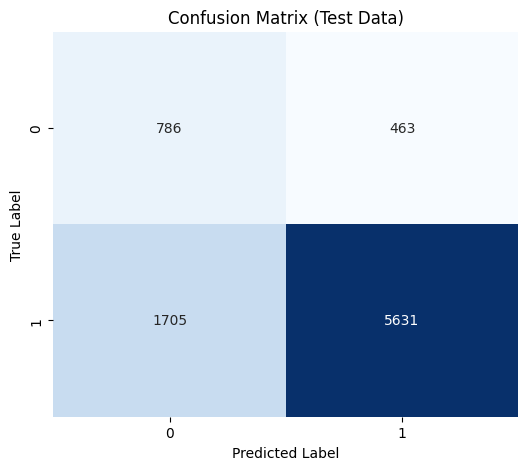

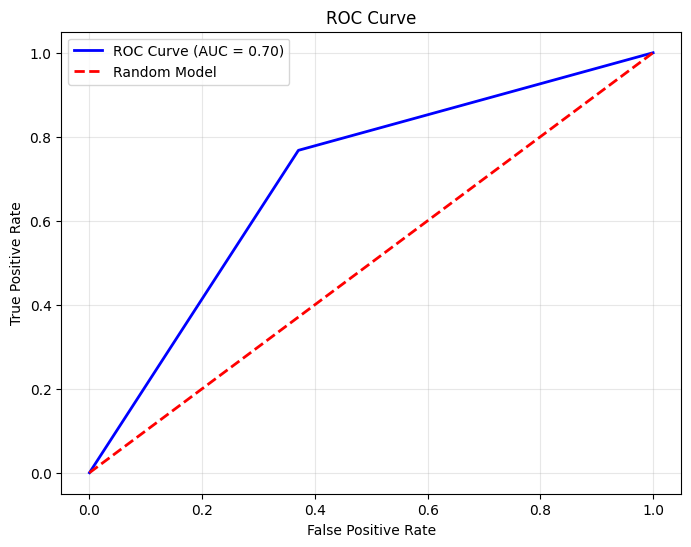

{'test_accuracy': 0.747466511357018,
 'test_precision': 0.9240236297998031,
 'test_recall': 0.7675845147219194,
 'test_f1': 0.8385703648548026,
 'test_roc_auc': 0.6984439787380614}

In [70]:
evaluate_binary_classification(lr5 , xtrain , ytrain_binarized , xtest , ytest_binarized)

Random forest models on binary data

In [71]:
rf4 = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=7 , n_jobs=-1)
rf4.fit(xtrain,ytrain_binarized)


,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.8743
Precision: 0.8734
Recall:    0.9975
F1 Score:  0.9313
ROC AUC:   0.5742

TESTING METRICS
Accuracy:  0.8733
Precision: 0.8742
Recall:    0.9948
F1 Score:  0.9306
ROC AUC:   0.5771

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.84      0.16      0.27      1249
           1       0.87      0.99      0.93      7336

    accuracy                           0.87      8585
   macro avg       0.86      0.58      0.60      8585
weighted avg       0.87      0.87      0.83      8585



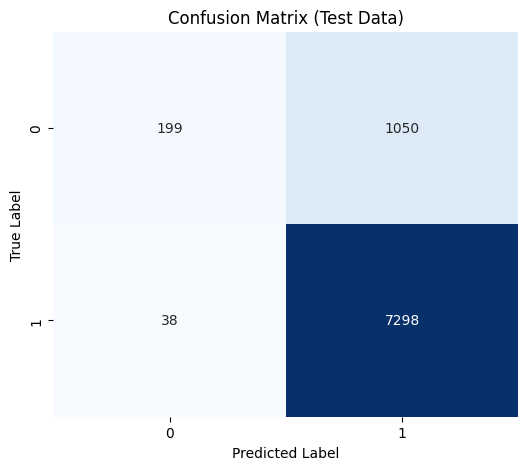

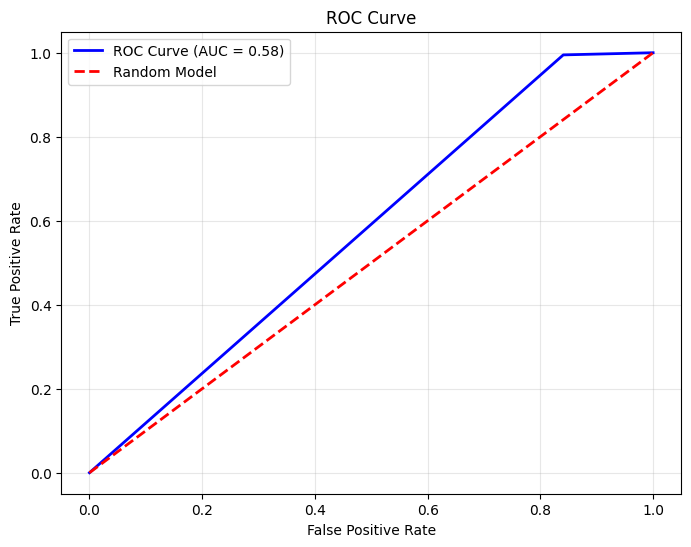

In [72]:

rf4_metrics = evaluate_binary_classification(rf4 , xtrain , ytrain_binarized , xtest , ytest_binarized)

In [73]:
rf5 = RandomForestClassifier(random_state = 7,n_estimators = 200 , max_depth = 10 , class_weight = 'balanced' )

rf5.fit(xtrain,ytrain_binarized)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.8027
Precision: 0.9274
Recall:    0.8345
F1 Score:  0.8785
ROC AUC:   0.7254

TESTING METRICS
Accuracy:  0.7966
Precision: 0.9221
Recall:    0.8323
F1 Score:  0.8749
ROC AUC:   0.7096

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.37      0.59      0.46      1249
           1       0.92      0.83      0.87      7336

    accuracy                           0.80      8585
   macro avg       0.65      0.71      0.67      8585
weighted avg       0.84      0.80      0.81      8585



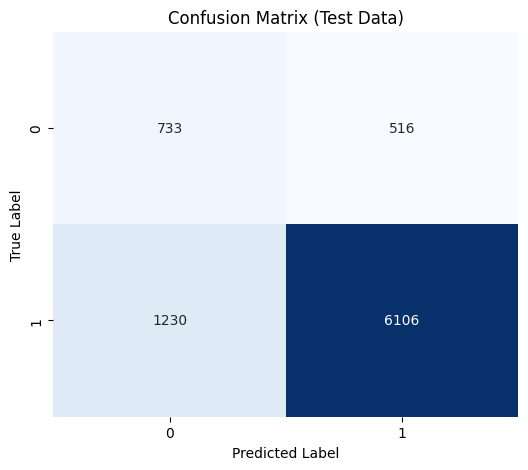

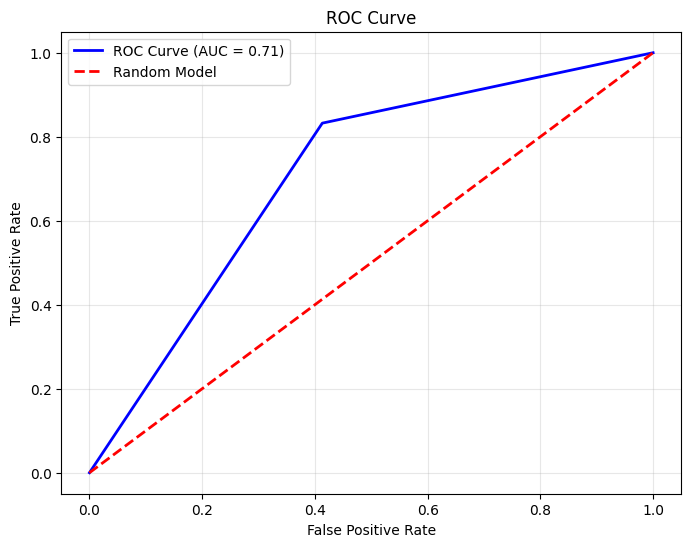

In [74]:
metrics_rf5 = evaluate_binary_classification(rf5 , xtrain,ytrain_binarized,xtest,ytest_binarized)

In [75]:
rf6 = RandomForestClassifier(random_state = 7,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf6.fit(xtrain,ytrain_binarized)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.9122
Precision: 0.9585
Recall:    0.9379
F1 Score:  0.9481
ROC AUC:   0.8496

TESTING METRICS
Accuracy:  0.8337
Precision: 0.9064
Recall:    0.8980
F1 Score:  0.9022
ROC AUC:   0.6768

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.43      0.46      0.44      1249
           1       0.91      0.90      0.90      7336

    accuracy                           0.83      8585
   macro avg       0.67      0.68      0.67      8585
weighted avg       0.84      0.83      0.84      8585



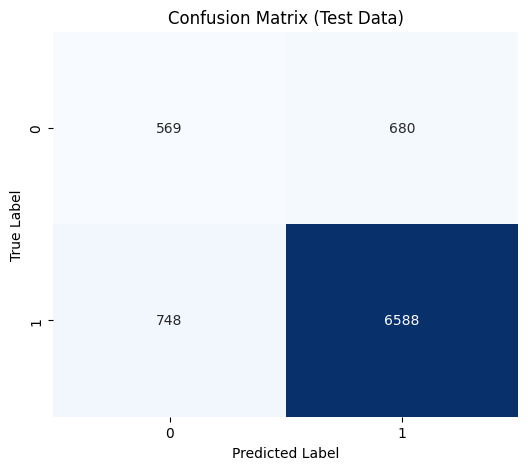

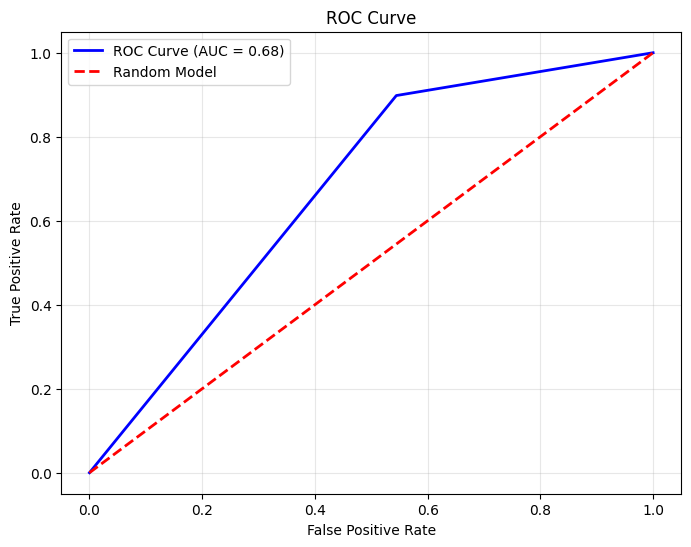

In [76]:
metrics_rf6 = evaluate_binary_classification(rf6 , xtrain,ytrain_binarized,xtest,ytest_binarized)


XGB model

In [77]:
counts = np.unique(ytrain_binarized,return_counts = True)[1]
neg_counts = counts[0]
pos_counts = counts[1]

ratio = neg_counts/pos_counts 

print(neg_counts)
print(pos_counts)
print(ratio)

11246
66018
0.17034748099003302


In [78]:
xgb2 = XGBClassifier(random_state = 7,
                    scale_pos_weight = ratio ,
                    objective = 'binary:logistic',
                    n_estimator = 200 ,
                    max_depth = 20,
                    learning_rate = 0.01,
                    eval_metric = "logloss")

xgb2.fit(xtrain,ytrain_binarized)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


TRAINING METRICS
Accuracy:  0.7852
Precision: 0.9633
Recall:    0.7782
F1 Score:  0.8609
ROC AUC:   0.8022

TESTING METRICS
Accuracy:  0.7338
Precision: 0.9252
Recall:    0.7490
F1 Score:  0.8279
ROC AUC:   0.6968

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.30      0.64      0.41      1249
           1       0.93      0.75      0.83      7336

    accuracy                           0.73      8585
   macro avg       0.61      0.70      0.62      8585
weighted avg       0.83      0.73      0.77      8585



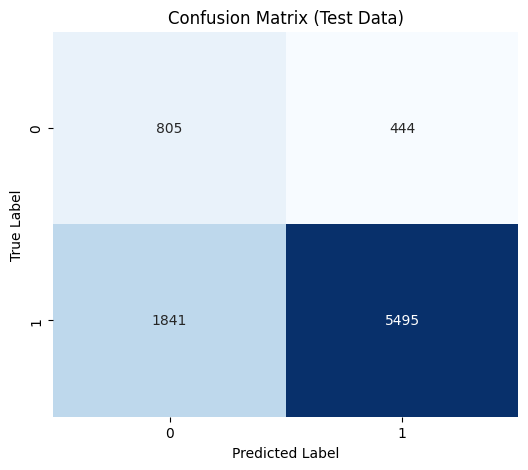

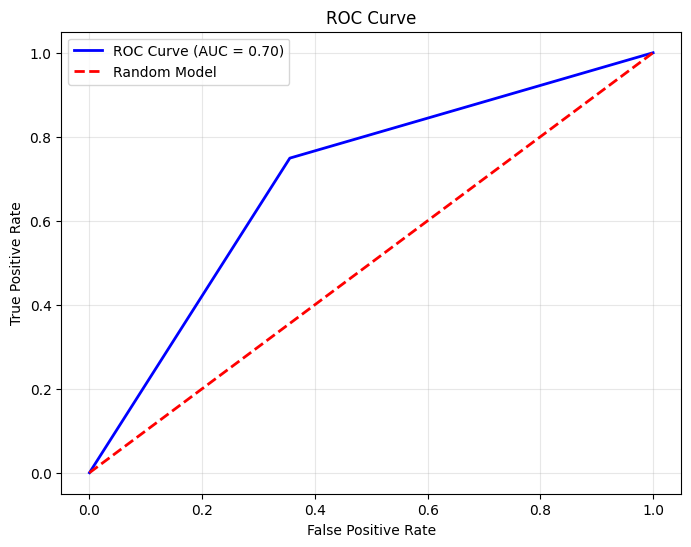

In [79]:
metrics_xgb2 = evaluate_binary_classification(xgb2,xtrain , ytrain_binarized,xtest , ytest_binarized)

### All Models Evaluation:


* Class Definition:

    * Class 0 (Negative): Dissatisfied customers

    * Class 1 (Positive): Satisfied customers



### For our business problem , we would like to find the best balance between Precision and Recall.
    * Recall : Of all dissatisfied customers, how many did we identify?

    * Precision : Of predicted dissatisfied customers, how many are actually dissatisfied?

### Therefore f1score - macro avg seems to be a critical metric.We will choose this metric as our primary evaluation metric for model comparison.


### Best model so far ::

   * Based on the Macro avg f1score metric , rf6 seems to be the best model with f1score of 0.68



In [80]:
joblib.dump(rf6 , f"{models_dir}/rf6.joblib")

['../data_analysis1/artifacts/models/rf6.joblib']

In [81]:
# saving the best model lr5 

import joblib 
joblib.dump(lr5 , f"{models_dir}/lr5.joblib")




['../data_analysis1/artifacts/models/lr5.joblib']

lr5 model has the highest recall for the class 0 so it is the best model at finding the most dissatisfied customers.Out of 100 dissatisfied customers this model is able to find 64 correctly as dissatisfied.

In [82]:
# Calculating binary class weights

class_counts = np.unique(ytrain_binarized,return_counts=True)
total_counts = len(ytrain_binarized)
class_weights_binary = {cls : round(total_counts/count,2) for cls,count in zip(class_counts[0] , class_counts[1])}
class_weights_binary

{np.int64(0): np.float64(6.87), np.int64(1): np.float64(1.17)}

Now we will try ann models

In [83]:
xtrain.shape , ytrain_binarized.shape , xtest.shape , ytest_binarized.shape

((77264, 139), (77264,), (8585, 139), (8585,))

In [84]:
# ann model 3

ann3 = Sequential()
ann3.add(Input(shape = (xtrain.shape[1],)))

ann3.add(Dense(256 , activation = 'relu'))
ann3.add(Dropout(0.1))

ann3.add(Dense(128, activation='relu',))
ann3.add(Dropout(0.1))

ann3.add(Dense(64, activation='relu',))
ann3.add(Dropout(0.1))

ann3.add(Dense(1, activation = 'sigmoid'))


ann3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,057 (301.00 KB)

 Trainable params: 77,057 (301.00 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
ann3.compile(optimizer = Adam(learning_rate = 0.01),
             loss = 'binary_crossentropy',
             metrics = ['accuracy']
             )


In [86]:
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.1,
                    patience = 5,
                              mode = 'min',
                              min_lr = 0.0001
                              )

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 15,
                           verbose = 1,
                           mode = 'min',
                           restore_best_weights = True)

history1 = ann3.fit(xtrain, ytrain_binarized,
                   validation_data=(xtest, ytest_binarized),
                   epochs=100, 
                   batch_size=32,
             callbacks = [reduce_lr , early_stop])     

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8678 - loss: 0.3606 - val_accuracy: 0.8748 - val_loss: 0.3430 - learning_rate: 0.0100
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8698 - loss: 0.3510 - val_accuracy: 0.8754 - val_loss: 0.3459 - learning_rate: 0.0100
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8698 - loss: 0.3511 - val_accuracy: 0.8593 - val_loss: 0.3524 - learning_rate: 0.0100
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8711 - loss: 0.3477 - val_accuracy: 0.8745 - val_loss: 0.3379 - learning_rate: 0.0100
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8714 - loss: 0.3464 - val_accuracy: 0.8740 - val_loss: 0.3436 - learning_rate: 0.0100
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8709 - loss: 0.3479 - val_accuracy: 0.8715 - val_loss: 0.3417 - learning_rate: 0.0100
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8

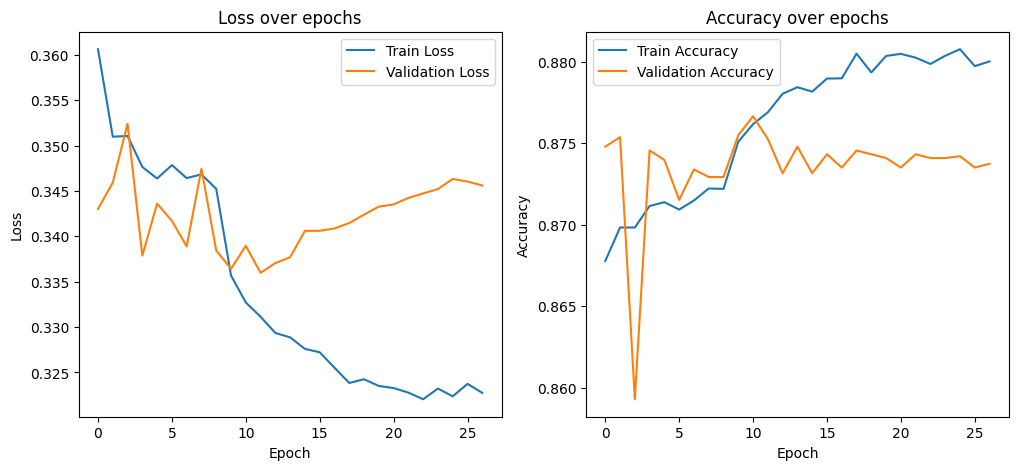

In [87]:
performance_plots(history1)

In [89]:
# Making classification report for ann3


# prediction probabilities
y_test_prob = ann3.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)

# Get recall for class 0 
recall_class_0 = recall_score(ytest_binarized , y_test_pred , pos_label = 0)
print(f"Recall for class 0 (Dissatisfied): {recall_class_0:.4f}")


269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.72      0.23      0.35      1249
   Satisfied (Class 1)       0.88      0.98      0.93      7336

              accuracy                           0.88      8585
             macro avg       0.80      0.61      0.64      8585
          weighted avg       0.86      0.88      0.85      8585

Recall for class 0 (Dissatisfied): 0.2338


ANN4

In [90]:
ann4 = Sequential()
ann4.add(Input(shape = (xtrain.shape[1],)))

ann4.add(Dense(256 , activation = 'relu'))
ann4.add(Dropout(0.1))

ann4.add(Dense(256 , activation = 'relu'))
ann4.add(Dropout(0.1))

ann4.add(Dense(128, activation='relu',))
ann4.add(Dropout(0.1))

ann4.add(Dense(64, activation='relu',))
ann4.add(Dropout(0.1))

ann4.add(Dense(1, activation = 'sigmoid'))


ann4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,849 (558.00 KB)

 Trainable params: 142,849 (558.00 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
ann4.compile(optimizer = Adam(learning_rate = 0.01),
             loss = 'binary_crossentropy',
             metrics = ['accuracy']
             )

In [92]:
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.1,
                              patience = 5,
                              mode = 'min',
                              min_lr = 0.0001
                              )

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 15,
                           verbose = 1,
                           mode = 'min',
                           restore_best_weights = True)

history2 = ann4.fit(xtrain, ytrain_binarized,
                   validation_data=(xtest, ytest_binarized),
                   epochs=100, 
                   batch_size=32,
                   class_weight = class_weights_binary,
             callbacks = [reduce_lr , early_stop])     

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7594 - loss: 1.2342 - val_accuracy: 0.8648 - val_loss: 0.5188 - learning_rate: 0.0100
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7611 - loss: 1.3288 - val_accuracy: 0.5839 - val_loss: 0.7543 - learning_rate: 0.0100
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7090 - loss: 1.2717 - val_accuracy: 0.8545 - val_loss: 0.6898 - learning_rate: 0.0100
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4649 - loss: 1.3887 - val_accuracy: 0.8545 - val_loss: 0.6715 - learning_rate: 0.0100
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5241 - loss: 1.3889 - val_accuracy: 0.8545 - val_loss: 0.6869 - learning_rate: 0.0100
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5055 - loss: 1.3868 - val_accuracy: 0.8545 - val_loss: 0.6614 - learning_rate: 0.0100
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6

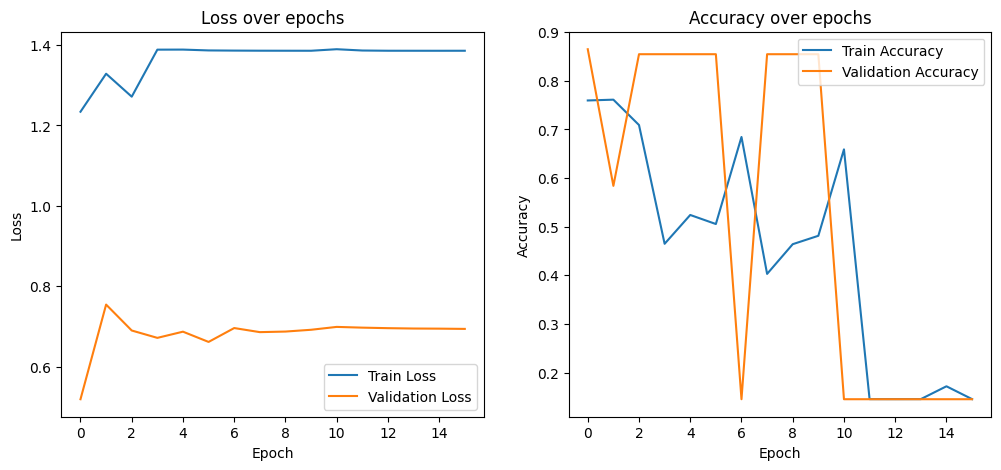

In [93]:
performance_plots(history2)

In [95]:
# Making classification report for ann3


# prediction probabilities
y_test_prob = ann4.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)


# Get recall for class 0 
recall_class_0 = recall_score(ytest_binarized , y_test_pred , pos_label = 0)
print(f"Recall for class 0 (Dissatisfied): {recall_class_0:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.56      0.33      0.42      1249
   Satisfied (Class 1)       0.89      0.96      0.92      7336

              accuracy                           0.86      8585
             macro avg       0.73      0.64      0.67      8585
          weighted avg       0.85      0.86      0.85      8585

Recall for class 0 (Dissatisfied): 0.3331


In [96]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

In [97]:
# ANN 5

ann5 = Sequential()
ann5.add(Input(shape=(xtrain.shape[1],)))

# Layer 1
ann5.add(Dense(512, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.1))

# Layer 2
ann5.add(Dense(256, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.1))

# Layer 3
ann5.add(Dense(128, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.1))

# Layer 4
ann5.add(Dense(64, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.1))

# Layer 5
ann5.add(Dense(32, activation='relu'))
ann5.add(Dropout(0.1))

# Layer 6
ann5.add(Dense(16, activation='relu'))
ann5.add(Dropout(0.1))

# Output layer
ann5.add(Dense(1, activation='sigmoid'))

ann5.summary()

# Compile with LOWER learning rate
ann5.compile(
    optimizer=Adam(learning_rate=0.01),  # Reduced from 0.1 to 0.001
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduced factor (less aggressive)
    patience=5,  # Increased patience
    mode='min',
    min_lr=0.00001
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,  # More patience to allow convergence
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# Train with class weights
history5 = ann5.fit(
    xtrain, ytrain_binarized,
    validation_data=(xtest, ytest_binarized),
    epochs=200,  # Increased epochs
    batch_size=32,
    class_weight=class_weights_binary,  # Critical for class 0
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 512)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,625 (979.00 KB)

 Trainable params: 248,705 (971.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7464 - loss: 1.2003 - val_accuracy: 0.8000 - val_loss: 0.6089 - learning_rate: 0.0100
Epoch 2/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7500 - loss: 1.1705 - val_accuracy: 0.8203 - val_loss: 0.5006 - learning_rate: 0.0100
Epoch 3/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7537 - loss: 1.1664 - val_accuracy: 0.8453 - val_loss: 0.5052 - learning_rate: 0.0100
Epoch 4/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7564 - loss: 1.1601 - val_accuracy: 0.7286 - val_loss: 0.5385 - learning_rate: 0.0100
Epoch 5/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7561 - loss: 1.1562 - val_accuracy: 0.7123 - val_loss: 0.5507 - learning_rate: 0.0100
Epoch 6/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7545 - loss: 1.1491 - val_accuracy: 0.7296 - val_loss: 0.5534 - learning_rate: 0.0100
Epoch 7/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.

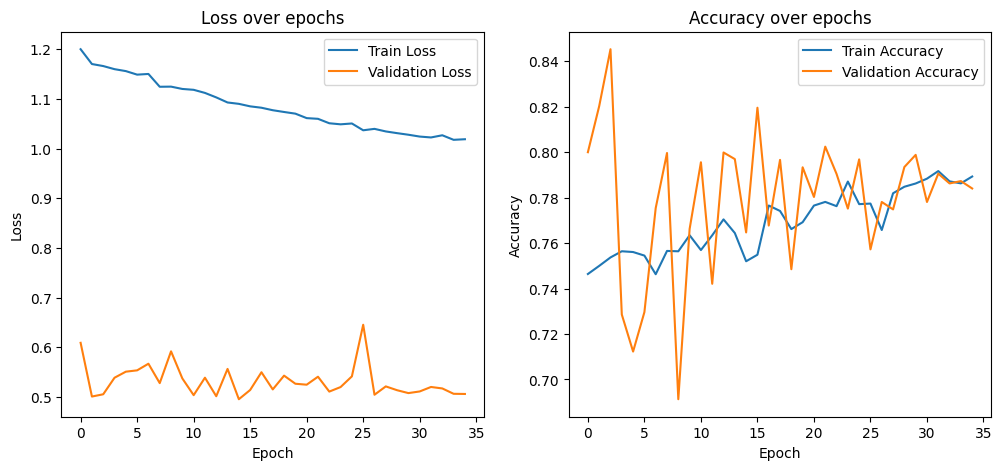

In [98]:
performance_plots(history5)

In [103]:
metrics_eval(ann5 , xtest , ytest_binarized)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
F1 Score : 0.6415
Precision: 0.6279
Recall: 0.7019


In [100]:
# prediction probabilities
y_test_prob = ann5.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)

# Get recall for class 0 
recall_class_0 = recall_score(ytest_binarized , y_test_pred , pos_label = 0)
print(f"Recall for class 0 (Dissatisfied): {recall_class_0:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.33      0.61      0.43      1249
   Satisfied (Class 1)       0.92      0.79      0.85      7336

              accuracy                           0.76      8585
             macro avg       0.63      0.70      0.64      8585
          weighted avg       0.84      0.76      0.79      8585

Recall for class 0 (Dissatisfied): 0.6133


This ann5 model has performed the best compared to other two previous ann models. This is able to predict dissatisfied class with atleast comparable performance to our some of the best models so far. The recall for the class 0 is 0.61 here. THe best model lr5 has the recall of 0.64. 

In [101]:
# saving the ann5 model

ann5.save(f"{models_dir}/ann5_model.keras")

| Model                         |   Test Accuracy | Test Precision (overall shown) | Test Recall (overall shown) | Test F1 (overall shown) |    ROC AUC (test) | Macro-avg F1 (from reports) |
| ----------------------------- | --------------: | -----------------------------: | --------------------------: | ----------------------: | ----------------: | --------------------------: |
| **lr5 (Logistic Regression)** |          0.7482 |                         0.9261 |                      0.7665 |                  0.8388 |            0.7035 |                        0.63 |
| **rf5 (Random Forest 5)**     |          0.7874 |                         0.9265 |                      0.8160 |                  0.8677 |            0.7178 |                        0.66 |
| **rf6 (Random Forest 6)**     |          0.8376 |                         0.9070 |                      0.9025 |                  0.9048 |            0.6795 |                        0.68 |
| **ann5 (ANN)**                | 0.78 (reported) |              — per-class shown |           — per-class shown |       — per-class shown | (no AUC reported) |    0.66 (macro from report) |


All the above mentioned models in the table are performing the best for our case but based on the final metric Recall for Class 0 to find the most dissatisfied customers - lr5 is the best scorer with 0.64 as recall score. We will take it as the best model.

MODEL TRAINING COMPLETED 